# Gradient boosting

## 1. First model
I train a gradient boosting classifier on the 11 pre-match features, on 2000-2021, and evaluate on 2022-2023.
I turn off the built-in early stopping, because it holds out a random 10% of matches, which mixes years.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd

from src.evaluation import compare, evaluate
from src.models.boosting import BoostingModel
from src.models.elo_logistic import EloLogistic
from src.splits import load_matches

matches = load_matches()
train = matches[matches["split"] == "train"]
valid = matches[matches["split"] == "valid"]

In [2]:
elo_model = EloLogistic().fit(train)
boosting = BoostingModel().fit(train)

compare({
    "elo_logistic": elo_model.predict_proba(valid),
    "boosting": boosting.predict_proba(valid),
}, valid["result"])

,log_loss,brier,rps
elo_logistic,0.8847,0.5197,0.1747
boosting,0.8926,0.5261,0.1768


In [3]:
pd.DataFrame({
    "train_log_loss": [evaluate(m.predict_proba(train), train["result"])["log_loss"] for m in [elo_model, boosting]],
    "valid_log_loss": [evaluate(m.predict_proba(valid), valid["result"])["log_loss"] for m in [elo_model, boosting]],
}, index=["elo_logistic", "boosting"]).round(4)

,train_log_loss,valid_log_loss
elo_logistic,0.8916,0.8847
boosting,0.8396,0.8926


The first boosting model is worse than the Elo baseline (0.8926 vs 0.8847).
It overfits: its training log loss is 0.8396 but its validation log loss is 0.8926, while the Elo baseline scores the same on both. With 300 trees of depth 3, it learns noise from 2000-2021 matches. I need a simpler model.

## 2. Experiment 1: number of trees
I change only `max_iter`. Depth 3, learning rate 0.05, 50 matches per leaf and seed 42 stay fixed.

In [4]:
rows = []
for n_trees in [25, 50, 100, 200, 300]:
    model = BoostingModel(max_iter=n_trees).fit(train)
    rows.append({
        "max_iter": n_trees,
        "train_log_loss": evaluate(model.predict_proba(train), train["result"])["log_loss"],
        **evaluate(model.predict_proba(valid), valid["result"]),
    })
pd.DataFrame(rows).round(4)

,max_iter,train_log_loss,log_loss,brier,rps
0,25,0.8902,0.8900,0.5222,0.1758
1,50,0.8762,0.8839,0.5197,0.1746
2,100,0.8653,0.8843,0.5206,0.1749
3,200,0.8514,0.8899,0.5241,0.1761
4,300,0.8396,0.8926,0.5261,0.1768


The training log loss keeps falling with more trees, but the validation log loss is lowest at 50 trees (0.8839) and rises after: beyond 50 trees, the model learns noise.
With 50 trees, boosting is only level with the Elo baseline (0.8847) and still behind Poisson (0.8743).

## 3. Experiment 2: tree depth
I change only `max_depth`, with 50 trees and the other settings fixed.

In [5]:
rows = []
for depth in [1, 2, 3, 4]:
    model = BoostingModel(max_iter=50, max_depth=depth).fit(train)
    rows.append({
        "max_depth": depth,
        "train_log_loss": evaluate(model.predict_proba(train), train["result"])["log_loss"],
        **evaluate(model.predict_proba(valid), valid["result"]),
    })
pd.DataFrame(rows).round(4)

,max_depth,train_log_loss,log_loss,brier,rps
0,1,0.8990,0.8950,0.5247,0.1769
1,2,0.8839,0.8855,0.5203,0.1749
2,3,0.8762,0.8839,0.5197,0.1746
3,4,0.8670,0.8822,0.5188,0.1742


Depth 1 underfits (0.8950). Depths 2 to 4 give 0.8855, 0.8839 and 0.8822: the differences are tiny, so I check whether they are real.

## 4. Are the differences real?
I compare models match by match on the same validation matches, and compute the mean log loss difference with its standard error. A difference smaller than about 2 standard errors can be explained by chance.

In [6]:
from src.database import query
from src.evaluation import paired_difference
from src.models.poisson import PoissonModel, rolling_predict

history = query("""
    SELECT date, home_team, away_team, home_score, away_score, neutral
    FROM clean_results
    ORDER BY date, match_id
""")
probs = {
    "elo_logistic": elo_model.predict_proba(valid),
    "boosting_depth_4": BoostingModel(max_iter=50, max_depth=4).fit(train).predict_proba(valid),
    "poisson": rolling_predict(lambda: PoissonModel(), history, valid),
}

pairs = [("boosting_depth_4", "elo_logistic"), ("poisson", "elo_logistic"), ("poisson", "boosting_depth_4")]
pd.DataFrame(
    [{"comparison": f"{a} - {b}", **paired_difference(probs[a], probs[b], valid["result"])} for a, b in pairs]
).round(4)

,comparison,mean_diff,std_error
0,boosting_depth_4 - elo_logistic,-0.0025,0.0036
1,poisson - elo_logistic,-0.0104,0.0056
2,poisson - boosting_depth_4,-0.0079,0.0057


Both differences against the Elo baseline are within about one standard error, so the boosting depth does not matter, and boosting is not better than the Elo baseline. Poisson is ahead of both, but not yet by 2 standard errors.

## 5. Experiment 3: feature ablation
I train the same boosting model with only the Elo gap and venue, then with all 11 features.

In [7]:
elo_features = ["elo_diff", "home_venue"]
rows = []
for name, features in [("elo_and_venue", elo_features), ("all_11", None)]:
    params = {"max_iter": 50, "max_depth": 4}
    if features is not None:
        params["features"] = features
    model = BoostingModel(**params).fit(train)
    rows.append({"features": name, **evaluate(model.predict_proba(valid), valid["result"])})
pd.DataFrame(rows).round(4)

,features,log_loss,brier,rps
0,elo_and_venue,0.8843,0.5206,0.1750
1,all_11,0.8822,0.5188,0.1742


With only the Elo gap and venue, boosting scores 0.8843, against 0.8822 with all 11 features. The gap is below one standard error: form and opponent-strength features add almost nothing, because the Elo rating already summarises recent results and opponent level.

## 6. Experiment 4: Poisson expected goals as features
I add the Poisson expected goals of both teams as features (stacking). For every match, they come from a Poisson model fitted at the start of the quarter, on earlier matches only.

In [8]:
from src.database import ROOT
from src.models.boosting import FEATURES
from src.models.poisson import rolling_expected_goals

cache = ROOT / "data" / "processed" / "poisson_expected_goals.csv"
if cache.exists():
    expected_goals = pd.read_csv(cache)
else:
    expected_goals = rolling_expected_goals(history, matches)
    expected_goals.to_csv(cache, index=False)

matches = matches.merge(expected_goals, on="match_id")
train = matches[matches["split"] == "train"]
valid = matches[matches["split"] == "valid"]

In [9]:
poisson_features = ["poisson_home_goals", "poisson_away_goals"]
feature_sets = {
    "elo_and_venue": ["elo_diff", "home_venue"],
    "elo_venue_poisson": ["elo_diff", "home_venue"] + poisson_features,
    "all_11_poisson": FEATURES + poisson_features,
}
rows = []
for name, features in feature_sets.items():
    model = BoostingModel(max_iter=50, max_depth=4, features=features).fit(train)
    rows.append({"features": name, **evaluate(model.predict_proba(valid), valid["result"])})
pd.DataFrame(rows).round(4)

,features,log_loss,brier,rps
0,elo_and_venue,0.8843,0.5206,0.1750
1,elo_venue_poisson,0.8713,0.5127,0.1714
2,all_11_poisson,0.8740,0.5135,0.1719


Adding the Poisson expected goals to the Elo gap and venue gives the best score so far (0.8713). Adding the 9 form features on top makes it slightly worse (0.8740), so I leave them out.
The expected goals carry the information the boosting model was missing: attack, defence and opponent level, weighted by recency.

In [10]:
stacking = BoostingModel(
    max_iter=50, max_depth=4, features=["elo_diff", "home_venue"] + poisson_features
).fit(train)
probs["stacking"] = stacking.predict_proba(valid)

pairs = [("stacking", "elo_logistic"), ("stacking", "poisson")]
pd.DataFrame(
    [{"comparison": f"{a} - {b}", **paired_difference(probs[a], probs[b], valid["result"])} for a, b in pairs]
).round(4)

,comparison,mean_diff,std_error
0,stacking - elo_logistic,-0.0134,0.0042
1,stacking - poisson,-0.0031,0.0034


Stacking beats the Elo baseline by 3.2 standard errors (-0.0134 ± 0.0042): this gap is real. Against Poisson alone, the gap (-0.0031 ± 0.0034) is within one standard error, so the two are statistically equivalent.
Machine learning alone did not beat a well-built statistical model. It only matches it when it uses the Poisson expected goals as features.

## 7. Calibration of the two finalists

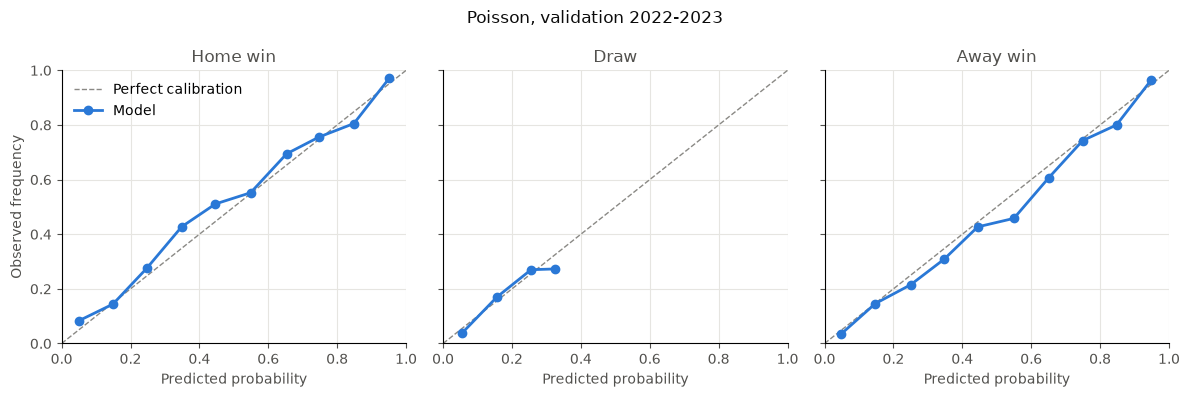

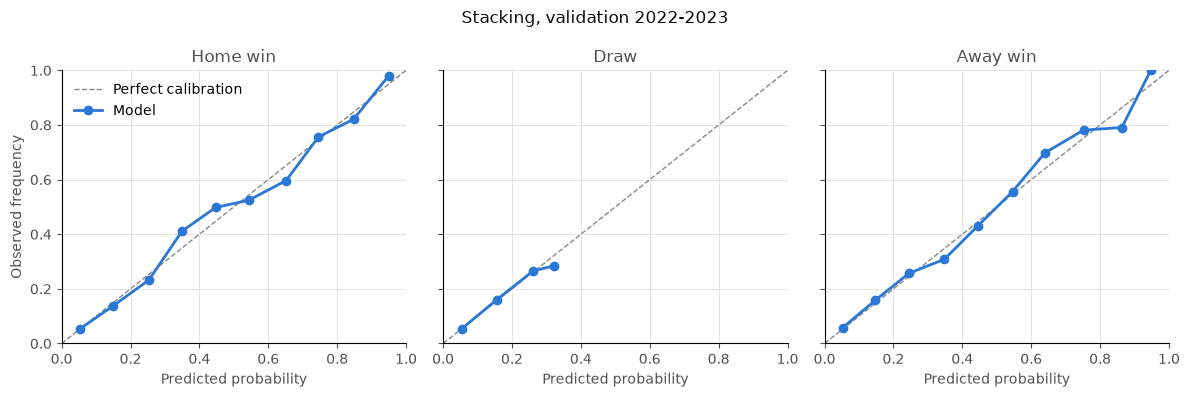

In [11]:
from src.plots import plot_calibration

for name in ["poisson", "stacking"]:
    fig = plot_calibration(probs[name], valid["result"], f"{name.capitalize()}, validation 2022-2023")
    fig.savefig(f"../reports/figures/calibration_{name}_valid.png", dpi=150, bbox_inches="tight")

Both finalists are well calibrated. Poisson is slightly underconfident on home wins around 30-45% and slightly overconfident on away wins around 55%. Stacking stays close to the diagonal: with 50 shallow trees, it does not show the overconfidence boosting is known for.
Both cap draw probabilities around 32%, with slight overconfidence in the top bin. No recalibration is needed.

## 8. Final model
Poisson and stacking are statistically equivalent on validation. I choose Poisson as the final model: it is simpler, interpretable (one attack and one defence per team), and it gives the probability of every score, which the tournament simulator needs for goal-difference tie-breakers and extra time. Stacking only gives home win, draw and away win.
I keep stacking as a documented alternative, and I will report both on the test set once.